In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [45]:
df = pd.read_csv('creditcard.csv')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [47]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [48]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [49]:
x = df.drop("Class",axis=1)
y= df['Class']

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [52]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(227845, 30)
(227845,)
(56962, 30)
(56962,)


In [53]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
model = LogisticRegression(max_iter=1000)

In [56]:
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [57]:
y_pred = model.predict(x_test)

In [58]:
from sklearn.metrics import accuracy_score
print('Accuracy :',accuracy_score(y_test,y_pred))

Accuracy : 0.9992099996488887


In [59]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[56849    15]
 [   30    68]]


## 📌 Model Evaluation – Why Accuracy Fails

- **Accuracy = 99%**, which appears very high.
- However, the dataset is highly imbalanced:
  - 99.8% Normal transactions
  - 0.17% Fraud transactions
- The model can achieve high accuracy simply by predicting most transactions as normal.
- Therefore, accuracy is misleading in fraud detection.
- Detecting fraud correctly is more important than predicting normal transactions correctly.

---

## 📌 Confusion Matrix

To properly evaluate performance, we use the **confusion matrix**.

In fraud detection:

- **False Negative (FN)** is very dangerous.
- A False Negative means a fraud transaction was predicted as normal.
- This directly causes financial loss to the bank.

---

## 📌 Recall

Recall measures:

\[
Recall = \frac{TP}{TP + FN}
\]

\[
Recall = \frac{68}{68 + 30} = 0.69
\]

**Recall = 69%**

This means the model detects only 69% of actual fraud cases.  
The remaining 31% fraud transactions are missed, which may cause significant financial loss.

---

## 📌 Precision

Precision measures:

\[
Precision = \frac{TP}{TP + FP}
\]

\[
Precision = \frac{68}{68 + 15} = 0.81
\]

**Precision = 81%**

This means when the model predicts fraud, it is correct 81% of the time.

---

## ⚠ Important Insight

- Recall is critical because missing fraud cases leads to financial loss.
- Precision is important because too many false fraud alerts affect customer experience.
- In imbalanced datasets, we focus more on Recall and Precision rather than Accuracy.


In [60]:
model_bal = LogisticRegression(max_iter=1000,class_weight='balanced')

In [61]:
model_bal.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [62]:
y_pred_bal = model_bal.predict(x_test)

In [63]:
print(confusion_matrix(y_test, y_pred_bal))

[[54665  2199]
 [    8    90]]


In [64]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_bal))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



Balanced Model
TP = 90
FN = 8
Recall = 90 / (90 + 8) ≈ 91.8%
FP = 2199
Precision = 90 / (90 + 2199) ≈ 3.9%
Accuracy ≈ 96%

In [65]:
y_prob = model.predict_proba(x_test)[:, 1]

In [66]:
y_pred_03 = (y_prob>=0.3).astype(int)

In [67]:
print(confusion_matrix(y_test,y_pred_03))

[[56844    20]
 [   25    73]]


In [68]:
print(classification_report(y_test,y_pred_03))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.74      0.76        98

    accuracy                           1.00     56962
   macro avg       0.89      0.87      0.88     56962
weighted avg       1.00      1.00      1.00     56962



## 📌 After Class Balancing – Moving to Probability-Based Decisions

After applying `class_weight='balanced'`, the model gives more importance to fraud cases during training.

However, even after balancing, the model still:

1. Predicts probabilities of fraud.
2. Converts probabilities into class labels (0 or 1) using a default threshold of 0.5.

---

## 📌 Probability Prediction

Logistic Regression does not directly predict fraud or normal.


It gives a probability between 0 and 1 for each transaction.

Example:

- 0.02 → Very unlikely fraud
- 0.87 → Highly likely fraud
- 0.45 → Moderate risk

---

## 📌 Default Threshold (0.5)

By default:

- If Probability ≥ 0.5 → Predict Fraud (1)
- If Probability < 0.5 → Predict Normal (0)

But this threshold is arbitrary.

In fraud detection, we may want to adjust it based on business cost.

---

## 📌 Why Threshold Tuning Is Important

Lower Threshold:
- Increases Recall
- Decreases Precision
- Catches more fraud
- Flags more normal transactions

Higher Threshold:
- Increases Precision
- Decreases Recall
- Misses more fraud
- Flags fewer normal transactions

---

## 📌 Key Insight

Class balancing changes how the model learns.

Threshold tuning changes how we convert probabilities into decisions.

Both techniques help handle class imbalance, but threshold tuning allows us to directly optimize business cost.

---

## 📌 Business Perspective

The optimal threshold is not the one with highest accuracy.

It is the threshold that minimizes total business loss:

In fraud detection, minimizing financial loss is more important than maximizing accuracy.

In [69]:
FN_cost = 10000   # Cost of missing a fraud
FP_cost = 100     # Cost of blocking a normal transaction

In [70]:
thresholds = np.arange(0.1,1.01,0.01)
best_threshold = 0
min_cost = float('inf')

In [71]:
for t in thresholds:
    y_pred_t = (y_prob>=t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test,y_pred_t).ravel()
    total_cost = fn * FN_cost +  fp * FP_cost
    if total_cost < min_cost:
        min_cost = total_cost
        best_threshold = t
print("Best Threshold:",best_threshold)
print("Minimum Cost:",min_cost)

Best Threshold: 0.1
Minimum Cost: 214500


In [72]:
y_final = (y_prob>=0.1).astype(int)
print(confusion_matrix(y_test,y_final))
print(classification_report(y_test,y_final))

[[56819    45]
 [   21    77]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.79      0.70        98

    accuracy                           1.00     56962
   macro avg       0.82      0.89      0.85     56962
weighted avg       1.00      1.00      1.00     56962



# 📌 Final Project Conclusion – Fraud Detection Optimization

## 🎯 Objective

The goal of this project was to build a fraud detection model and optimize it not just for accuracy, but for real-world business cost.

---

## ❌ Why Accuracy Failed

The dataset was highly imbalanced:

- 99.8% Normal transactions  
- 0.17% Fraud transactions  

The baseline Logistic Regression model achieved:

- Accuracy ≈ 99%

However, accuracy was misleading because the model could predict most transactions as normal and still achieve high performance.

Fraud detection requires focusing on correctly identifying fraud cases, not maximizing overall accuracy.

---

## 📊 Baseline Model Performance (Threshold = 0.5)

- Recall (Fraud) = 69%
- Precision (Fraud) = 82%
- Total Business Cost ≈ ₹301,500

The model missed 31% of fraud transactions, leading to significant financial loss.

---

## ⚖ Class Imbalance Handling

We applied `class_weight='balanced'` to penalize fraud misclassification more heavily.

This increased recall but caused a sharp drop in precision due to excessive false positives.

This demonstrated the trade-off between recall and precision.

---

## 💡 Moving to Cost-Based Optimization

Instead of optimizing for recall or precision alone, we defined a business cost function:

\[
\text{Total Cost} = (FN \times 10,000) + (FP \times 100)
\]

Where:

- False Negative (FN) → Direct financial fraud loss
- False Positive (FP) → Customer inconvenience & operational cost

We then systematically evaluated thresholds from 0.0 to 1.0.

---

## ✅ Optimal Threshold Found

- **Best Threshold = 0.10**
- **Minimum Cost = ₹214,500**

Final Performance at Threshold = 0.10:

- Recall (Fraud) ≈ 79%
- Precision (Fraud) ≈ 63%
- Significant reduction in total business cost

---

## 🧠 Key Insights

- Machine learning models predict probabilities, not final decisions.
- The decision threshold controls the trade-off between recall and precision.
- Class imbalance affects evaluation metrics.
- Business cost should drive model optimization, not accuracy.
- Threshold tuning can significantly reduce real-world financial loss without retraining the model.

---

## 🏆 Final Outcome

By separating:

1. Learning layer (probability estimation)
2. Decision layer (threshold selection)
3. Business layer (cost evaluation)



### RANDOM FOREST

In [73]:
from sklearn.ensemble import RandomForestClassifier

In [74]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

In [75]:
rf_model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [76]:
rf_proba = rf_model.predict_proba(x_test)[:,1]

In [77]:
thresholds

array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 ,
       0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31,
       0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42,
       0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53,
       0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64,
       0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75,
       0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86,
       0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97,
       0.98, 0.99, 1.  ])

In [78]:
best_threshold = None
min_cost = float('inf')
for t in thresholds:
    y_pred_rf = (rf_proba >= t).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test,y_pred_rf).ravel()
    rf_total_cost = fn * FN_cost + fp * FP_cost
    if rf_total_cost < min_cost:
        min_cost = rf_total_cost
        best_threshold = t


In [79]:
print("Best Threshold:", best_threshold)
print("Minimum Cost:", min_cost)

Best Threshold: 0.13
Minimum Cost: 122300


In [80]:
y_pred_rf = (rf_proba >= best_threshold).astype(int)

In [81]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.88      0.83        98

    accuracy                           1.00     56962
   macro avg       0.89      0.94      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [82]:
print(confusion_matrix(y_test,y_pred_rf))

[[56841    23]
 [   12    86]]


## Random Forest Model

After training a Logistic Regression model, we trained a Random Forest classifier to improve fraud detection performance. Random Forest is an ensemble learning algorithm that combines multiple decision trees to produce more stable and accurate predictions.

### Steps Performed

**1. Model Training**

A Random Forest classifier was trained using the training dataset.

Key parameters used:
- `n_estimators = 100` → number of decision trees
- `random_state = 42` → ensures reproducibility
- `class_weight = 'balanced'` → adjusts weights to handle class imbalance

The model was trained using:

rf_model.fit(x_train, y_train)

---

**2. Probability Prediction**

Instead of directly predicting classes, the model predicted fraud probabilities using:

rf_proba = rf_model.predict_proba(x_test)[:,1]

This returns the probability that a transaction belongs to the fraud class.

---

**3. Threshold Optimization**

Since fraud detection requires minimizing financial loss, we tested multiple probability thresholds from **0.00 to 1.00**.

For each threshold:
- Probabilities were converted into predictions
- Confusion matrix was calculated
- Business cost was computed using:

Cost = (FN × 10000) + (FP × 100)

The threshold with the **lowest total cost** was selected as the optimal threshold.

---

**4. Optimal Threshold**

Best Threshold: **0.13**  
Minimum Business Cost: **₹122,300**

This threshold provided the best balance between detecting fraud cases and minimizing false alarms.

---

**5. Model Evaluation**

Using the optimized threshold, the model achieved:

- Precision (Fraud): **0.79**
- Recall (Fraud): **0.88**
- F1-score: **0.83**

The confusion matrix showed that the model successfully detected most fraud transactions while keeping false positives low.

This demonstrates that Random Forest performs well for detecting complex fraud patterns.

## Model Comparison

Two models were evaluated for the fraud detection task:

1. Logistic Regression
2. Random Forest

Because the dataset is highly imbalanced (~0.17% fraud), accuracy is not a reliable metric. Instead, models were compared based on **precision, recall, and business cost**.

### Cost Function

To simulate real-world financial impact, the following cost function was used:

Cost = (FN × 10000) + (FP × 100)

- False Negative (FN): Missing a fraud transaction → ₹10,000 loss
- False Positive (FP): Incorrect fraud alert → ₹100 investigation cost

---

### Model Results

| Model | Best Threshold | Minimum Business Cost |
|------|------|------|
| Logistic Regression | 0.10 | ₹214,500 |
| Random Forest | 0.13 | ₹122,300 |

---

### Key Observations

- Random Forest significantly reduced financial loss compared to Logistic Regression.
- The optimized Random Forest model reduced business cost by **₹92,200**.
- This represents a **43% reduction in financial loss**.

Random Forest performed better because it can capture **non-linear patterns and complex relationships** in the data, while Logistic Regression assumes a linear relationship.

---

### Conclusion

Random Forest was selected as the final model because it achieved:

- Higher fraud detection capability
- Lower financial loss
- Better balance between recall and precision

This demonstrates the advantage of ensemble models for complex classification problems such as fraud detection.

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score

In [85]:
fpr, tpr, thresholds = roc_curve(y_test, rf_proba)

In [87]:
auc_score = roc_auc_score(y_test, rf_proba)

print("AUC Score:", auc_score)

AUC Score: 0.952908497036969


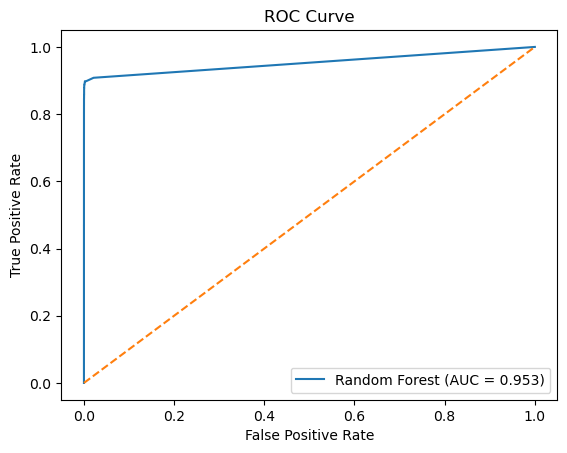

In [91]:
plt.figure()

plt.plot(fpr, tpr, label="Random Forest (AUC = %.3f)" % auc_score)

plt.plot([0,1], [0,1], linestyle='--')  

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Feature Importance

In [94]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf_model.feature_importances_
})

In [96]:
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

In [99]:
top_features = feature_importance.head(10)

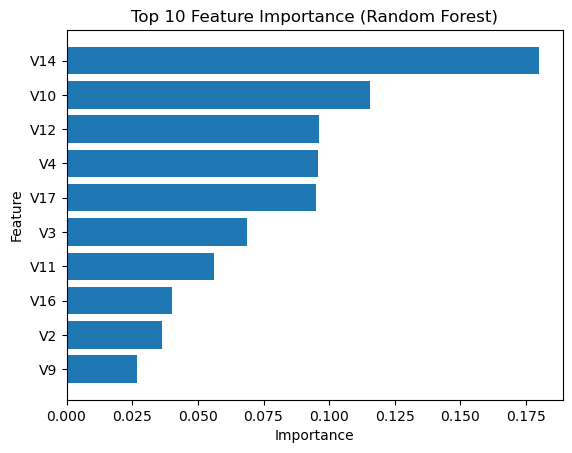

In [109]:
plt.figure()
plt.barh(top_features["Feature"],top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

## ROC Curve and AUC Score

The Receiver Operating Characteristic (ROC) curve is used to evaluate the ability of the model to distinguish between fraudulent and normal transactions across different classification thresholds.

The ROC curve plots:

- **False Positive Rate (FPR)** on the X-axis  
- **True Positive Rate (TPR)** on the Y-axis  

False Positive Rate:

FPR = FP / (FP + TN)

True Positive Rate (Recall):

TPR = TP / (TP + FN)

Each point on the ROC curve represents a different classification threshold. As the threshold changes, the balance between detecting fraud (TPR) and generating false alarms (FPR) also changes.

A good model will produce a curve that rises quickly toward the **top-left corner**, meaning it detects a large proportion of fraud transactions while keeping false positives low.

The diagonal line on the ROC graph represents a **random classifier**. Any useful model should perform significantly above this line.

### Area Under the Curve (AUC)

The Area Under the Curve (AUC) summarizes the ROC curve into a single value between 0 and 1. It measures the model’s overall ability to rank fraudulent transactions higher than normal transactions.

Interpretation of AUC values:

| AUC Score | Interpretation |
|----------|---------------|
| 0.5 | Random guessing |
| 0.7 – 0.8 | Acceptable model |
| 0.8 – 0.9 | Good model |
| 0.9+ | Excellent model |

A higher AUC score indicates that the model has a stronger ability to separate fraud and normal transactions across different thresholds.

---

## Feature Importance

Random Forest models provide a built-in measure of **feature importance**, which indicates how much each feature contributes to the model’s predictions.

Feature importance is calculated based on how much each feature reduces impurity when the decision trees split the data. Features that consistently help separate fraud and normal transactions will receive higher importance scores.

By examining feature importance, we can:

- Identify which variables are most influential in fraud detection
- Improve model interpretability
- Gain insights into patterns associated with fraudulent behavior

In this project, the top features identified by the Random Forest model played a significant role in distinguishing fraudulent transactions from normal ones. Understanding these features helps explain how the model makes decisions and provides additional insights into fraud patterns.

In [110]:
from sklearn.metrics import precision_recall_curve

In [112]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_proba)

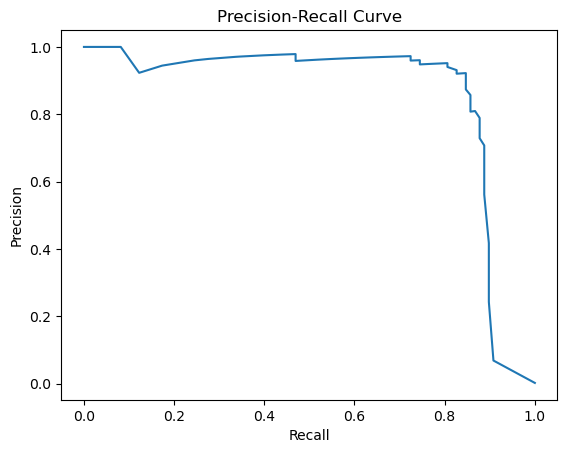

In [113]:
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [115]:
from sklearn.metrics import average_precision_score

ap_score = average_precision_score(y_test, rf_proba)

print("Average Precision:", ap_score)

Average Precision: 0.8541999432510914


## Precision–Recall Curve

The Precision–Recall (PR) curve is an evaluation metric commonly used for highly imbalanced classification problems such as fraud detection. Since fraudulent transactions represent a very small portion of the dataset, traditional metrics like accuracy or even ROC curves can sometimes provide an overly optimistic view of model performance.

The Precision–Recall curve focuses specifically on the performance of the model when predicting the **positive class (fraud)**.

The curve plots:

- **Recall** on the X-axis  
- **Precision** on the Y-axis  

### Recall

Recall measures how many of the actual fraud transactions were correctly detected by the model.

Recall = TP / (TP + FN)

A high recall means the model successfully identifies most fraud cases.

---

### Precision

Precision measures how many of the transactions predicted as fraud were actually fraudulent.

Precision = TP / (TP + FP)

High precision means fewer normal transactions are incorrectly flagged as fraud.

---

### Precision–Recall Trade-off

In fraud detection, there is usually a trade-off between precision and recall:

- Increasing recall helps detect more fraud cases.
- However, increasing recall often lowers precision because more normal transactions may be flagged as fraud.

The Precision–Recall curve helps visualize how precision changes as the model attempts to detect more fraudulent transactions.

---

### Why Precision–Recall Curve is Important

For highly imbalanced datasets like fraud detection, the Precision–Recall curve is often more informative than the ROC curve because it focuses on the performance of the minority class.

A strong fraud detection model should maintain **high precision while achieving high recall**, meaning it detects most fraud cases while minimizing false alarms.

## Key Learnings

This project demonstrated the challenges of building machine learning models for highly imbalanced datasets such as fraud detection. Instead of relying on accuracy, the model was evaluated using precision, recall, and business cost to better reflect real-world impact.

Threshold optimization proved critical in minimizing financial loss by balancing fraud detection with false alerts. Additionally, evaluation tools such as ROC curves, Precision–Recall curves, and feature importance helped assess model performance and interpret how the model detects fraudulent transactions.

Overall, the Random Forest model provided strong fraud detection capability while significantly reducing business loss compared to the baseline model.